In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
file_path = '/content/drive/MyDrive/ML Proje/Heart_Disease_Prediction.csv'
df = pd.read_csv(file_path)
display(df.head())

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


Label'ı Sayıya Çevirme

Random Forest sayısal veri ister.

In [6]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Presence":1,
    "Absence":0
})

In [7]:
X = df.drop("Heart Disease", axis=1)

y = df["Heart Disease"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

TAHMİN

In [10]:
y_pred = model.predict(X_test)

MODEL DEĞERLENDİRME

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8703703703703703

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.94      0.90        33
           1       0.89      0.76      0.82        21

    accuracy                           0.87        54
   macro avg       0.88      0.85      0.86        54
weighted avg       0.87      0.87      0.87        54


Confusion Matrix
[[31  2]
 [ 5 16]]


Random Forest modeli kullanılarak kalp hastalığı tahmini yapılmıştır. Model test verisi üzerinde %87 doğruluk elde etmiş ve özellikle sağlıklı bireyleri yüksek doğrulukla sınıflandırmıştır. Bununla birlikte bazı hastalık vakalarının kaçırıldığı gözlemlenmiştir. Bu nedenle model klinik karar destek sistemi olarak değerlendirilebilir.

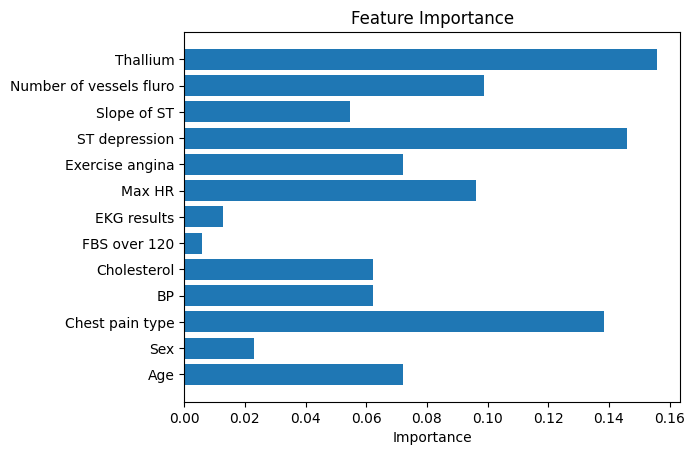

In [12]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

Random Forest modeli kullanılarak yapılan kalp hastalığı tahmin çalışmasında modelin hangi özelliklere daha fazla önem verdiği feature importance analizi ile incelenmiştir. Elde edilen sonuçlara göre modelin karar verirken özellikle Thallium testi, ST depresyonu ve göğüs ağrısı tipi değişkenlerine daha yüksek ağırlık verdiği görülmektedir. Bu değişkenler klinik literatürde de kalp hastalıklarının teşhisinde önemli göstergeler arasında yer almaktadır. Özellikle Thallium testi kalp kasına giden kan akışını değerlendiren bir test olduğu için model tarafından en önemli özellik olarak belirlenmesi tıbbi açıdan anlamlı bir sonuçtur. Benzer şekilde egzersiz sırasında ortaya çıkan ST depresyonu ve göğüs ağrısının tipi de kalp hastalığı riskini belirlemede önemli rol oynamaktadır.

Bunun yanında maksimum kalp atım hızı (Max HR) ve damar sayısı (Number of vessels) gibi değişkenler de model tarafından orta seviyede önemli özellikler olarak değerlendirilmiştir. Bu özellikler kalbin egzersiz performansı ve damar tıkanıklığı hakkında bilgi verdiği için hastalık tahmininde katkı sağlamaktadır. Diğer taraftan kolesterol, kan basıncı ve yaş gibi değişkenler model tarafından daha düşük önem değerleri almıştır. Bunun nedeni bu değişkenlerin tek başına kalp hastalığını belirlemede yeterli olmaması veya veri setindeki dağılımlarının sınırlı olması olabilir. Ayrıca FBS over 120, EKG sonuçları ve cinsiyet gibi özelliklerin model üzerindeki etkisinin daha düşük olduğu görülmüştür.

Genel olarak değerlendirildiğinde modelin özellikle klinik test sonuçlarına dayalı değişkenleri daha güçlü sinyaller olarak kullandığı görülmektedir. Bu durum modelin veri setindeki anlamlı tıbbi örüntüleri öğrenebildiğini göstermektedir. Feature importance analizi sayesinde modelin karar mekanizması daha anlaşılır hale gelmiş ve hangi özelliklerin kalp hastalığı tahmininde daha etkili olduğu ortaya konmuştur. Bu tür analizler makine öğrenmesi modellerinin yorumlanabilirliğini artırmak ve elde edilen sonuçların güvenilirliğini değerlendirmek açısından önemli bir rol oynamaktadır.